<a href="https://colab.research.google.com/github/YugeshwarV/TripFare/blob/main/TripFare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TripFare : Predicting Urban Taxi Fare with Machine Learning

In [ ]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from math import radians, sin, cos, sqrt, atan2

from scipy.stats import uniform, randint

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor

from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor, XGBClassifier

from sklearn.feature_selection import mutual_info_regression, RFE, SelectKBest, chi2

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV

import pickle

### Step 1 & 2 : Data Collection & Data Understanding

In [ ]:
df = pd.read_csv("taxi_fare.csv")

In [ ]:
df.shape

(212345, 18)

In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'RatecodeID',
 'store_and_fwd_flag',
 'dropoff_longitude',
 'dropoff_latitude',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount']

In [ ]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count            int64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag        object
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

In [ ]:
df.describe()

,VendorID,passenger_count,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000,212345.000000
mean,1.708338,1.766493,-73.112122,40.279405,1.034152,-73.144178,40.295648,1.324943,12.665588,0.048077,0.497662,1.809357,0.329049,0.299637,15.649355
std,0.454529,1.469647,7.936633,4.370714,0.494699,7.794599,4.293031,0.478255,10.875584,0.148103,0.037436,2.507419,2.028199,0.014094,13.592129
min,1.000000,0.000000,-121.933327,0.000000,1.000000,-121.933327,0.000000,1.000000,-52.000000,-0.500000,-0.500000,-2.700000,0.000000,-0.300000,-52.800000
25%,1.000000,1.000000,-73.990891,40.740292,1.000000,-73.990570,40.740089,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.300000
50%,2.000000,1.000000,-73.979469,40.755989,1.000000,-73.978691,40.755508,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.620000
75%,2.000000,2.000000,-73.963295,40.770283,1.000000,-73.964645,40.767475,2.000000,14.500000,0.000000,0.500000,2.360000,0.000000,0.300000,17.160000
max,2.000000,6.000000,0.000000,42.786934,99.000000,0.000000,42.786934,4.000000,819.500000,4.500000,0.500000,218.950000,661.080000,0.300000,832.800000


In [ ]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64

In [ ]:
df.duplicated().sum()

0

### Step 3 : Feature Engineering

In [ ]:
print((df["pickup_longitude"] == 0).sum())
print((df["pickup_latitude"] == 0).sum())
print((df["dropoff_longitude"] == 0).sum())
print((df["dropoff_latitude"] == 0).sum())

2471
2471
2383
2383


In [ ]:
df = df[
    (df["pickup_longitude"] != 0) &
    (df["pickup_latitude"] != 0) &
    (df["dropoff_longitude"] != 0) &
    (df["dropoff_latitude"] != 0)
]

In [ ]:
df.reset_index(drop = True, inplace = True)

In [ ]:
df.shape

(209649, 18)

In [ ]:
df.describe()

,VendorID,passenger_count,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000,209649.000000
mean,1.710817,1.769043,-73.972948,40.753652,1.030413,-73.974352,40.752992,1.324008,12.648071,0.048018,0.497868,1.809045,0.329566,0.299685,15.632242
std,0.453384,1.471814,0.235471,0.031690,0.318042,0.185372,0.033562,0.477568,10.749080,0.147717,0.035757,2.491341,2.035321,0.013295,13.483276
min,1.000000,0.000000,-121.933327,37.389389,1.000000,-121.933327,37.389328,1.000000,-52.000000,-0.500000,-0.500000,-2.340000,0.000000,-0.300000,-52.800000
25%,1.000000,1.000000,-73.990997,40.741035,1.000000,-73.990723,40.740768,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.300000
50%,2.000000,1.000000,-73.979782,40.756149,1.000000,-73.978889,40.755730,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.620000
75%,2.000000,2.000000,-73.964027,40.770489,1.000000,-73.965698,40.767712,2.000000,14.500000,0.000000,0.500000,2.360000,0.000000,0.300000,17.160000
max,2.000000,6.000000,-7.587607,42.786934,99.000000,-71.063591,42.786934,4.000000,819.500000,1.000000,0.500000,218.950000,661.080000,0.300000,832.800000


### Haversine formula

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

In [ ]:
# calculating trip distance using haversine formula

df["trip_distance_km"] = df.apply(
    lambda row: haversine(
        row["pickup_latitude"], row["pickup_longitude"],
        row["dropoff_latitude"], row["dropoff_longitude"]
    ), axis=1
)

In [ ]:
df = df[df["trip_distance_km"] > 2]

In [ ]:
df = df[df["trip_distance_km"] < 45]

In [ ]:
df.shape

(102322, 19)

In [ ]:
df.loc[:, "pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df.loc[:, "pickup_day"] = df["pickup_datetime"].dt.weekday

In [ ]:
df.loc[:, "is_weekend"] = df["pickup_day"].isin([5, 6]).astype(int)

In [ ]:
df["pickup_day"].unique()

array([1, 3])

In [ ]:
df["pickup_datetime"].dtypes

dtype('<M8[ns]')

In [ ]:
df.loc[:, "am_or_pm"] = df["pickup_datetime"].dt.strftime("%p")

In [ ]:
df.loc[:, "hour"] = df["pickup_datetime"].dt.hour
df.loc[:, "is_night"] = df["hour"].apply(lambda x: 1 if (x >= 22 or x < 5) else 0)

In [ ]:
df.loc[:, "dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

In [ ]:
df.loc[:, "trip_duration_min"] = (df["dropoff_datetime"] - df["pickup_datetime"]).dt.total_seconds() / 60

In [ ]:
df = df[df["trip_duration_min"] > 3 ]

In [ ]:
df = df[df["trip_duration_min"] <= 45 ]

In [ ]:
df.shape

(97596, 27)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97596 entries, 0 to 209648
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               97596 non-null  int64         
 1   tpep_pickup_datetime   97596 non-null  object        
 2   tpep_dropoff_datetime  97596 non-null  object        
 3   passenger_count        97596 non-null  int64         
 4   pickup_longitude       97596 non-null  float64       
 5   pickup_latitude        97596 non-null  float64       
 6   RatecodeID             97596 non-null  int64         
 7   store_and_fwd_flag     97596 non-null  object        
 8   dropoff_longitude      97596 non-null  float64       
 9   dropoff_latitude       97596 non-null  float64       
 10  payment_type           97596 non-null  int64         
 11  fare_amount            97596 non-null  float64       
 12  extra                  97596 non-null  float64       
 13  mta_t

In [ ]:
# Calculating Fare per kilometer and Fare per minute

df["fare_per_km"] = df["fare_amount"] / df["trip_distance_km"]
df["fare_per_min"] = df["fare_amount"] / df["trip_duration_min"]

In [ ]:
df = df[df["fare_amount"] >= 5 ]

In [ ]:
df.reset_index(drop = True, inplace = True)

In [ ]:
df = df[df["passenger_count"] > 0]

In [ ]:
df = df[df["fare_per_km"] >= 2]

In [ ]:
df = df[df["fare_per_km"] <= 8]

In [ ]:
df = df[df["fare_per_min"] >= 0.5]

In [ ]:
df = df[df["fare_per_min"] <= 2]

In [ ]:
df = df[df["fare_amount"] <= 30 ]

In [ ]:
df = df[df["trip_duration_min"] <= 35 ]

In [ ]:
df = df[df["trip_distance_km"] <= 8 ]

In [ ]:
df[["trip_distance_km", "trip_duration_min", "fare_amount", "passenger_count", "fare_per_km", "fare_per_min"]].describe()

,trip_distance_km,trip_duration_min,fare_amount,passenger_count,fare_per_km,fare_per_min
count,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000
mean,3.616096,16.493373,13.592343,1.760796,3.950616,0.873130
std,1.447705,6.583035,4.429019,1.462922,0.981568,0.203879
min,2.000010,2.833333,5.000000,1.000000,2.000172,0.500379
25%,2.463332,11.416667,10.000000,1.000000,3.227089,0.722222
50%,3.156135,15.616667,12.500000,1.000000,3.807369,0.820669
75%,4.408277,20.783333,16.500000,2.000000,4.527786,0.973783
max,7.999547,35.000000,30.000000,6.000000,7.995849,2.000000


In [ ]:
df.reset_index(drop = True, inplace = True)

In [ ]:
df.describe()

,VendorID,passenger_count,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,...,trip_distance_km,pickup_datetime,pickup_day,is_weekend,hour,is_night,dropoff_datetime,trip_duration_min,fare_per_km,fare_per_min
count,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000,81441.000000,...,81441.000000,81441,81441.000000,81441.0,81441.000000,81441.000000,81441,81441.000000,81441.000000,81441.000000
mean,1.703159,1.760796,-73.977229,40.754456,1.000577,-73.976664,40.752452,1.288479,13.592343,0.060762,...,3.616096,2016-03-04 16:56:11.693532672,1.740831,0.0,8.430668,0.103732,2016-03-04 17:12:41.295919872,16.493373,3.950616,0.873130
min,1.000000,1.000000,-74.037590,40.579857,1.000000,-74.041481,40.582329,1.000000,5.000000,0.000000,...,2.000010,2016-03-01 00:00:00,1.000000,0.0,0.000000,0.000000,2016-03-01 00:05:10,2.833333,2.000172,0.500379
25%,1.000000,1.000000,-73.992088,40.737816,1.000000,-73.992073,40.737862,1.000000,10.000000,0.000000,...,2.463332,2016-03-01 07:47:04,1.000000,0.0,7.000000,0.000000,2016-03-01 08:02:25,11.416667,3.227089,0.722222
50%,2.000000,1.000000,-73.980255,40.756321,1.000000,-73.979088,40.755280,1.000000,12.500000,0.000000,...,3.156135,2016-03-01 10:29:47,1.000000,0.0,9.000000,0.000000,2016-03-01 10:48:27,15.616667,3.807369,0.820669
75%,2.000000,2.000000,-73.963921,40.773270,1.000000,-73.966118,40.767044,2.000000,16.500000,0.000000,...,4.408277,2016-03-10 09:15:13,3.000000,0.0,11.000000,0.000000,2016-03-10 09:33:34,20.783333,4.527786,0.973783
max,2.000000,6.000000,-73.716240,40.892803,5.000000,-73.696976,40.893005,4.000000,30.000000,1.000000,...,7.999547,2016-03-10 14:55:39,3.000000,0.0,14.000000,1.000000,2016-03-10 15:27:54,35.000000,7.995849,2.000000
std,0.456869,1.462922,0.024622,0.026151,0.042770,0.026444,0.028018,0.458848,4.429019,0.163669,...,1.447705,NaN,0.965838,0.0,3.237441,0.304914,NaN,6.583035,0.981568,0.203879


### Step 4 : Exploratory Data Analysis (EDA)

In [ ]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,...,pickup_datetime,pickup_day,is_weekend,am_or_pm,hour,is_night,dropoff_datetime,trip_duration_min,fare_per_km,fare_per_min
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,-73.976746,40.765152,1,N,-74.004265,40.746128,...,2016-03-01 00:00:00,1,0,AM,0,1,2016-03-01 00:07:55,7.916667,2.867981,1.136842
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,-73.983482,40.767925,1,N,-74.005943,40.733166,...,2016-03-01 00:00:00,1,0,AM,0,1,2016-03-01 00:11:06,11.100000,2.556159,0.990991
2,1,2016-03-01 00:00:01,2016-03-01 00:16:04,1,-73.788773,40.647758,1,N,-73.829208,40.712345,...,2016-03-01 00:00:01,1,0,AM,0,1,2016-03-01 00:16:04,16.050000,2.578595,1.277259
3,2,2016-03-01 00:00:01,2016-03-01 00:24:06,3,-73.985779,40.741192,1,N,-73.946350,40.797878,...,2016-03-01 00:00:01,1,0,AM,0,1,2016-03-01 00:24:06,24.083333,3.298563,0.975779
4,1,2016-03-01 00:00:02,2016-03-01 00:07:49,1,-73.969818,40.797428,1,N,-73.943771,40.796200,...,2016-03-01 00:00:02,1,0,AM,0,1,2016-03-01 00:07:49,7.783333,3.641636,1.027837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81436,1,2016-03-01 12:15:35,2016-03-01 12:35:36,1,-73.968102,40.762638,1,N,-73.965996,40.803867,...,2016-03-01 12:15:35,1,0,PM,12,0,2016-03-01 12:35:36,20.016667,3.487427,0.799334
81437,2,2016-03-01 12:15:35,2016-03-01 12:33:48,2,-73.975220,40.755638,1,N,-73.990707,40.740189,...,2016-03-01 12:15:35,1,0,PM,12,0,2016-03-01 12:33:48,18.216667,5.562831,0.658737
81438,1,2016-03-01 12:15:37,2016-03-01 12:37:29,1,-73.995956,40.753887,1,N,-74.010605,40.703121,...,2016-03-01 12:15:37,1,0,PM,12,0,2016-03-01 12:37:29,21.866667,3.201634,0.846037
81439,2,2016-03-01 12:15:37,2016-03-01 12:38:53,1,-73.955688,40.782261,1,N,-73.974915,40.751282,...,2016-03-01 12:15:37,1,0,PM,12,0,2016-03-01 12:38:53,23.266667,4.203580,0.687679


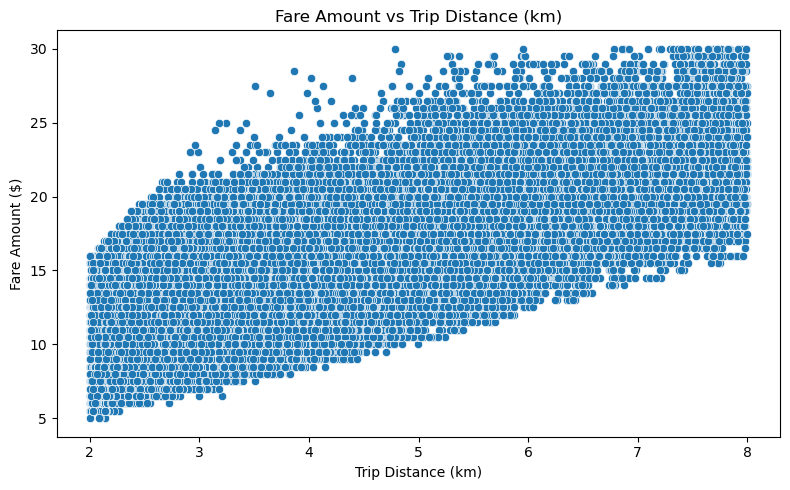

In [ ]:
# Fare vs. Distance - Scatterplot to examine how fare amounts vary with trip distance

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="trip_distance_km", y="fare_amount")
plt.title("Fare Amount vs Trip Distance (km)")
plt.xlabel("Trip Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.tight_layout()
plt.show()

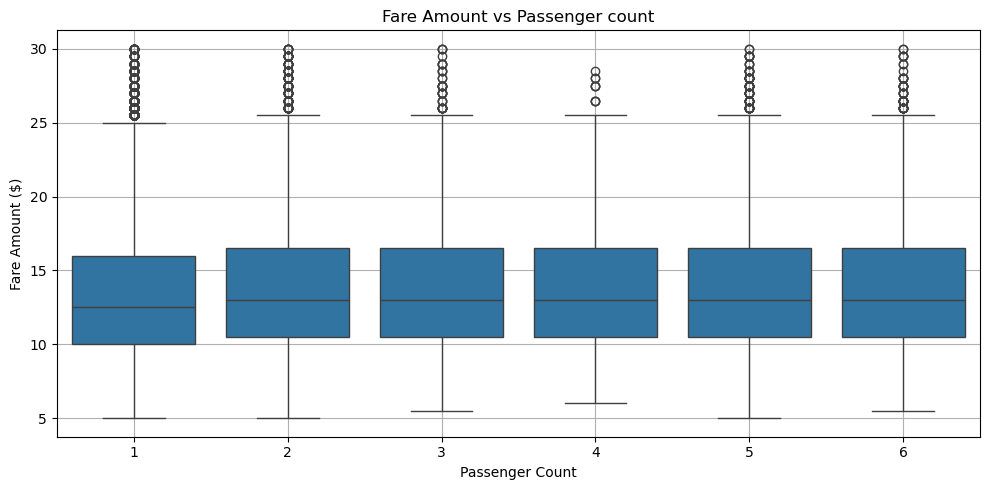

In [ ]:
# Fare vs. Passenger Count - Box plot to analyze the relationship between fare and the number of passengers.

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="passenger_count", y="fare_amount")
plt.title("Fare Amount vs Passenger count")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

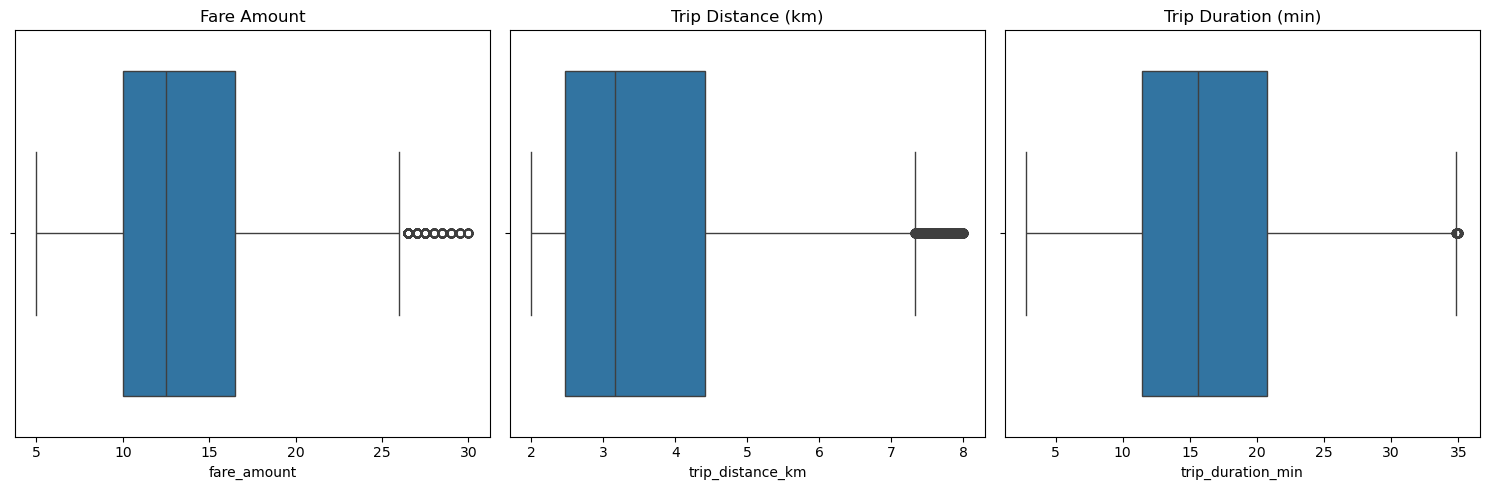

In [ ]:
# 3. Outlier detection with boxplots
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x=df["fare_amount"])
plt.title("Fare Amount")

plt.subplot(1, 3, 2)
sns.boxplot(x=df["trip_distance_km"])
plt.title("Trip Distance (km)")

plt.subplot(1, 3, 3)
sns.boxplot(x=df["trip_duration_min"])
plt.title("Trip Duration (min)")

plt.tight_layout()
plt.show()

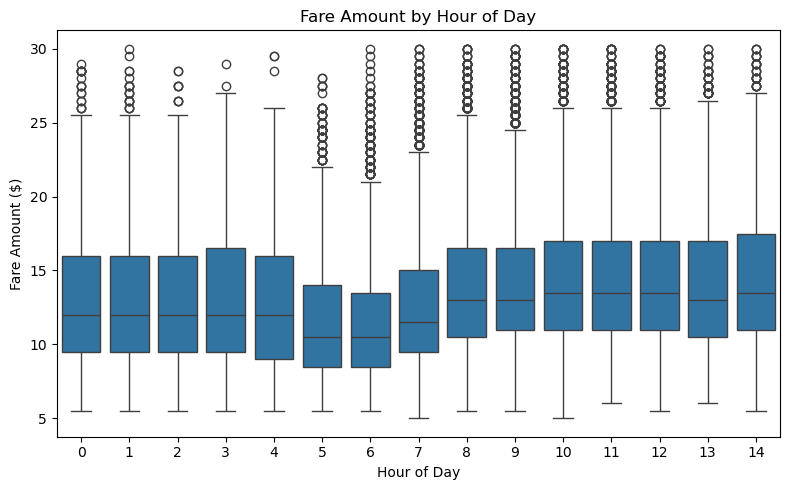

In [ ]:
# 4. Fare amount by hour of day

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="hour", y="fare_amount")
plt.title("Fare Amount by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fare Amount ($)")
plt.tight_layout()
plt.show()


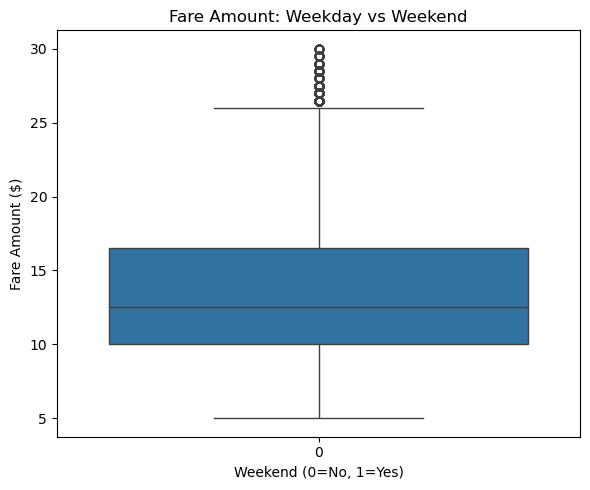

In [ ]:
# 5. Fare amount: Weekday vs Weekend
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="is_weekend", y="fare_amount")
plt.title("Fare Amount: Weekday vs Weekend")
plt.xlabel("Weekend (0=No, 1=Yes)")
plt.ylabel("Fare Amount ($)")
plt.tight_layout()
plt.show()

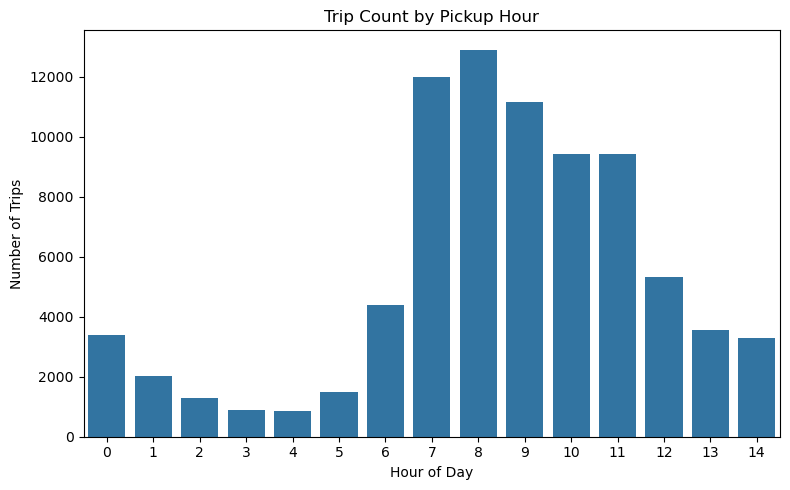

In [ ]:
# 6. Trip Count by Pickup Hour

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="hour")
plt.title("Trip Count by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

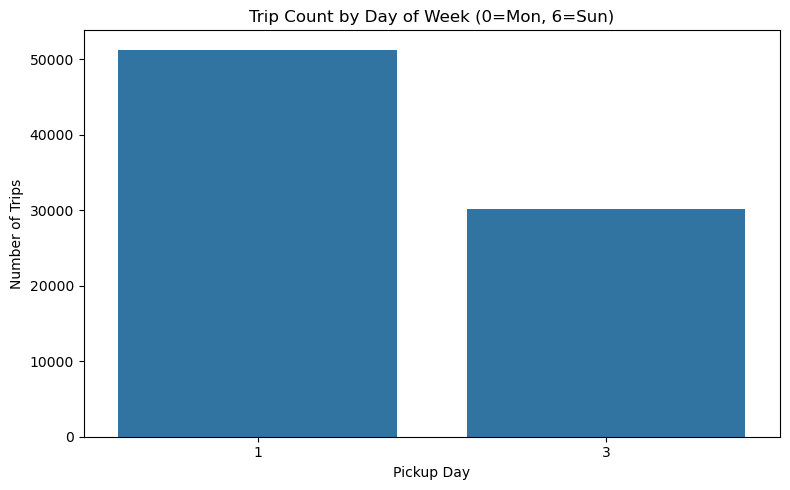

In [ ]:
# 7. Trip Count by Pickup Day
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="pickup_day")
plt.title("Trip Count by Day of Week (0=Mon, 6=Sun)")
plt.xlabel("Pickup Day")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()


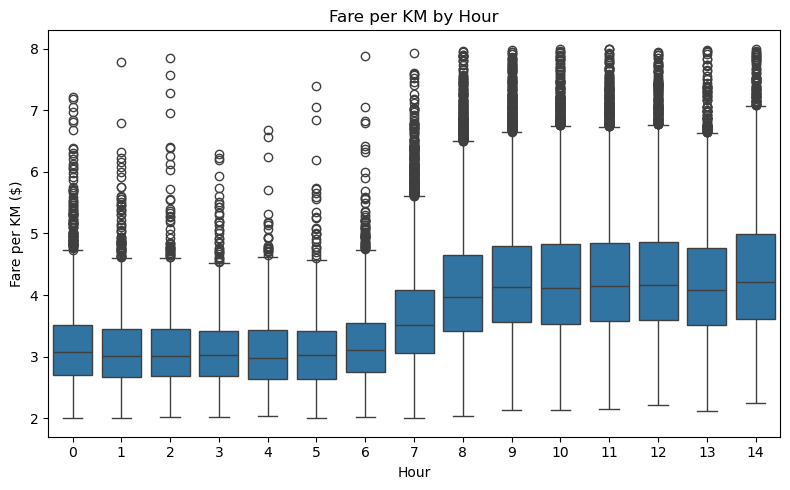

In [ ]:
# 8. Fare per KM across hours
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="hour", y="fare_per_km")
plt.title("Fare per KM by Hour")
plt.xlabel("Hour")
plt.ylabel("Fare per KM ($)")
plt.tight_layout()
plt.show()

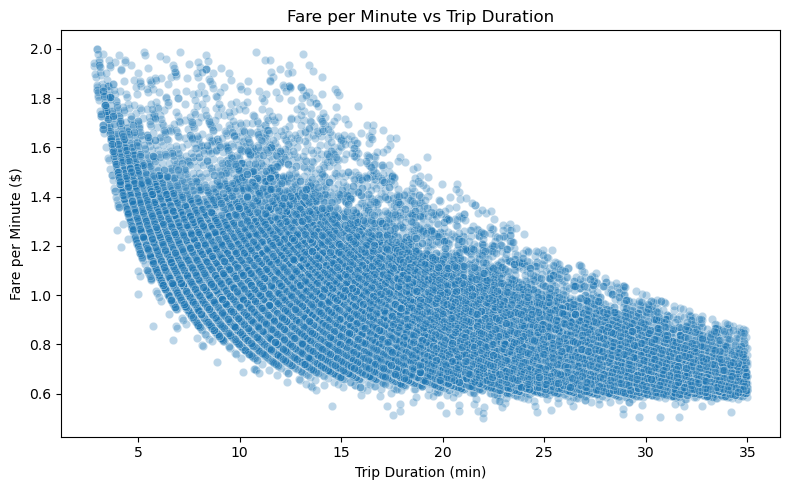

In [ ]:
# 9. Fare per Minute vs Trip Duration
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="trip_duration_min", y="fare_per_min", alpha=0.3)
plt.title("Fare per Minute vs Trip Duration")
plt.xlabel("Trip Duration (min)")
plt.ylabel("Fare per Minute ($)")
plt.tight_layout()
plt.show()

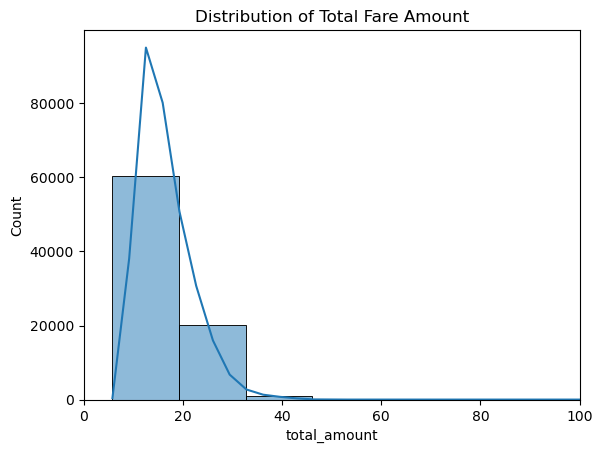

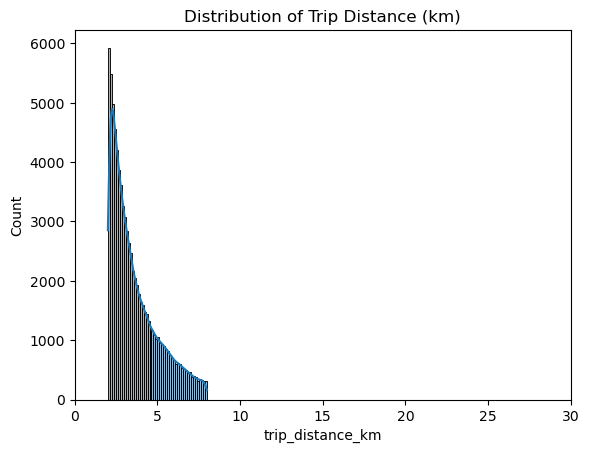

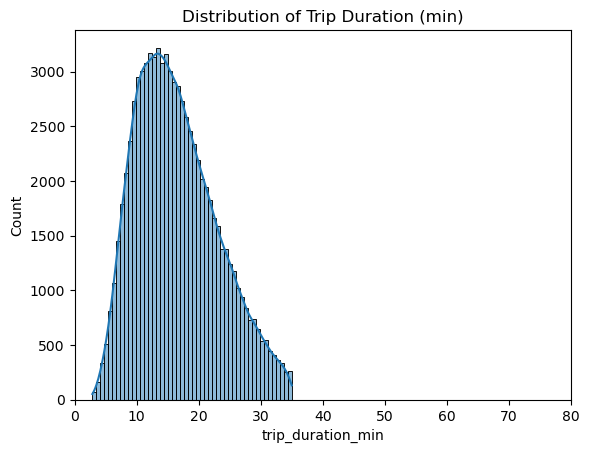

In [ ]:
# Fare distribution
sns.histplot(df["total_amount"], bins=50, kde=True)
plt.title("Distribution of Total Fare Amount")
plt.xlim(0,100)
plt.show()

# Trip distance
sns.histplot(df["trip_distance_km"], bins=50, kde=True)
plt.title("Distribution of Trip Distance (km)")
plt.xlim(0,30)
plt.show()

# Trip duration
sns.histplot(df["trip_duration_min"], bins=50, kde=True)
plt.title("Distribution of Trip Duration (min)")
plt.xlim(0,80)
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81441 entries, 0 to 81440
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               81441 non-null  int64         
 1   tpep_pickup_datetime   81441 non-null  object        
 2   tpep_dropoff_datetime  81441 non-null  object        
 3   passenger_count        81441 non-null  int64         
 4   pickup_longitude       81441 non-null  float64       
 5   pickup_latitude        81441 non-null  float64       
 6   RatecodeID             81441 non-null  int64         
 7   store_and_fwd_flag     81441 non-null  object        
 8   dropoff_longitude      81441 non-null  float64       
 9   dropoff_latitude       81441 non-null  float64       
 10  payment_type           81441 non-null  int64         
 11  fare_amount            81441 non-null  float64       
 12  extra                  81441 non-null  float64       
 13  m

In [ ]:
num_features = [
    "trip_distance_km", "trip_duration_min", "passenger_count",
    "fare_per_km", "fare_per_min", "hour", "pickup_day",
    "is_night", "fare_amount", "extra", "mta_tax", "RatecodeID", "improvement_surcharge", "tolls_amount", "tip_amount",
    "payment_type", "passenger_count", "VendorID", "total_amount"
]

corr_matrix = df[num_features].corr()

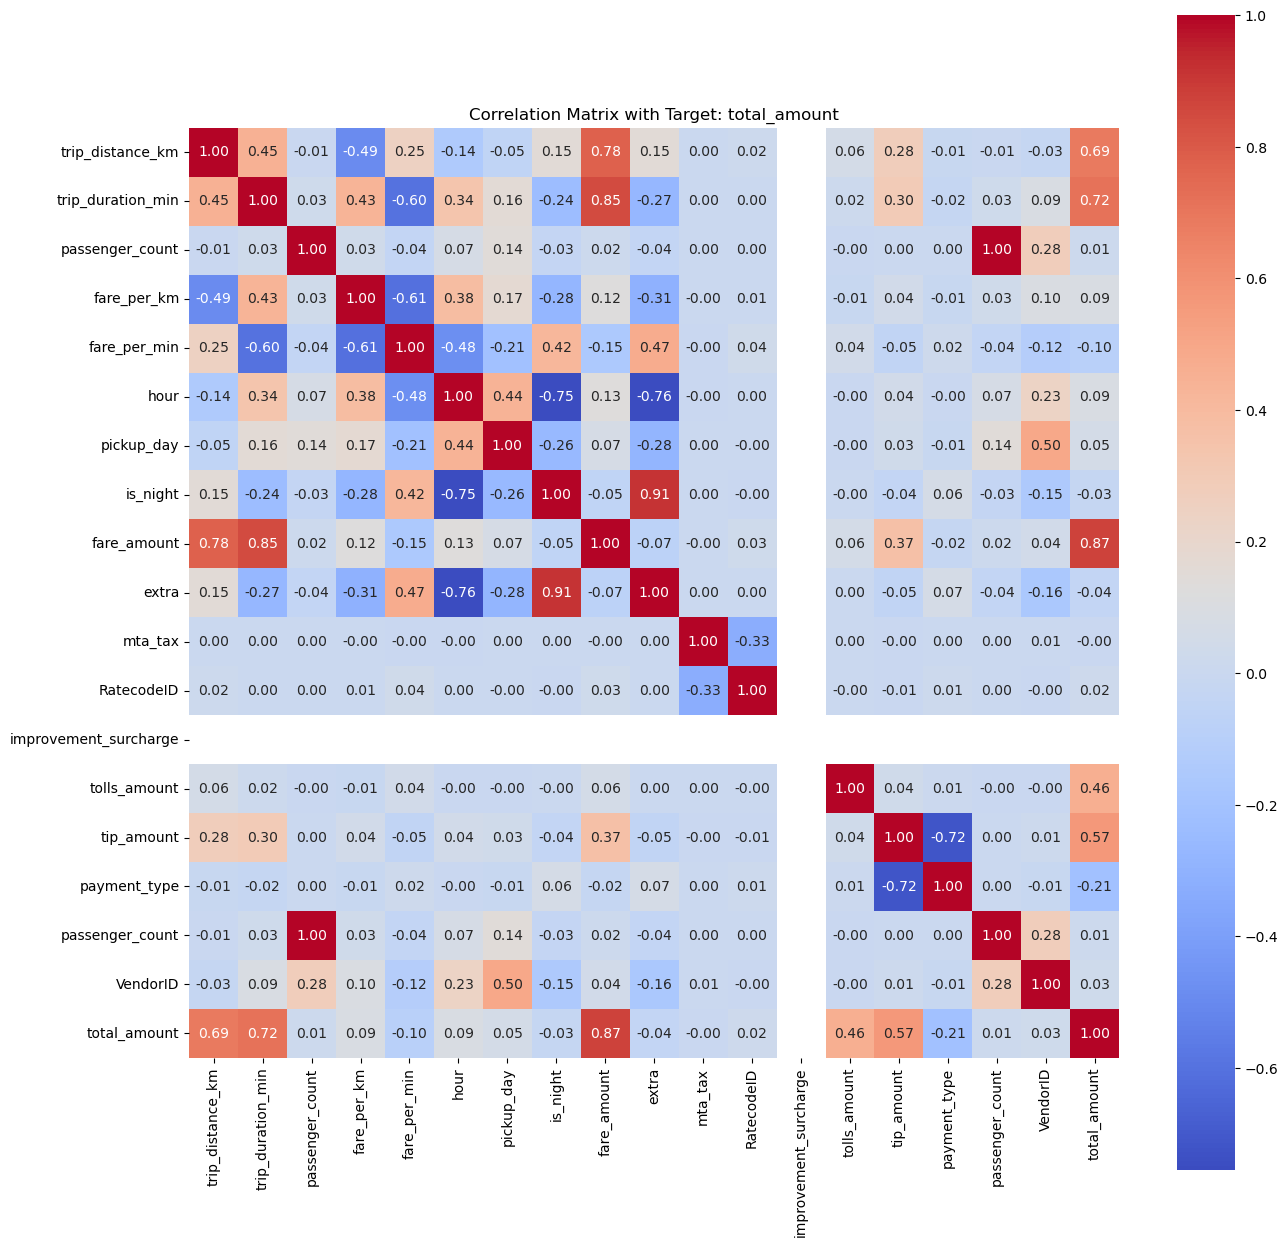

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix with Target: total_amount")
plt.show()


In [ ]:
corr_matrix

,trip_distance_km,trip_duration_min,passenger_count,fare_per_km,fare_per_min,hour,pickup_day,is_night,fare_amount,extra,mta_tax,RatecodeID,improvement_surcharge,tolls_amount,tip_amount,payment_type,passenger_count,VendorID,total_amount
trip_distance_km,1.000000,0.446541,-0.005180,-0.488010,0.251653,-0.141523,-0.053639,0.152359,0.779749,0.154321,0.000131,0.018726,NaN,0.056229,0.278853,-0.008761,-0.005180,-0.026634,0.690058
trip_duration_min,0.446541,1.000000,0.032858,0.432985,-0.602417,0.338002,0.156806,-0.237175,0.846745,-0.270912,0.000999,0.001671,NaN,0.016543,0.298928,-0.023138,0.032858,0.088274,0.718043
passenger_count,-0.005180,0.032858,1.000000,0.033516,-0.039332,0.068733,0.144800,-0.031332,0.018734,-0.035708,0.001822,0.000833,NaN,-0.001910,0.004296,0.001205,1.000000,0.279971,0.013493
fare_per_km,-0.488010,0.432985,0.033516,1.000000,-0.608828,0.383136,0.173758,-0.279391,0.122682,-0.307554,-0.000930,0.005330,NaN,-0.011177,0.044661,-0.010848,0.033516,0.097289,0.091464
fare_per_min,0.251653,-0.602417,-0.039332,-0.608828,1.000000,-0.478823,-0.212399,0.420363,-0.152009,0.473281,-0.002631,0.035666,NaN,0.042815,-0.047054,0.024526,-0.039332,-0.116683,-0.096709
hour,-0.141523,0.338002,0.068733,0.383136,-0.478823,1.000000,0.442859,-0.753281,0.134328,-0.755384,-0.001699,0.000156,NaN,-0.002867,0.044113,-0.004456,0.068733,0.234934,0.091002
pickup_day,-0.053639,0.156806,0.144800,0.173758,-0.212399,0.442859,1.000000,-0.260948,0.071419,-0.283133,0.002688,-0.000838,NaN,-0.001913,0.033908,-0.010725,0.144800,0.498370,0.054429
is_night,0.152359,-0.237175,-0.031332,-0.279391,0.420363,-0.753281,-0.260948,1.000000,-0.053473,0.911898,0.001192,-0.001766,NaN,-0.000692,-0.040578,0.064325,-0.031332,-0.148901,-0.026441
fare_amount,0.779749,0.846745,0.018734,0.122682,-0.152009,0.134328,0.071419,-0.053473,1.000000,-0.071372,-0.001114,0.031157,NaN,0.059024,0.365626,-0.022712,0.018734,0.044197,0.874430
extra,0.154321,-0.270912,-0.035708,-0.307554,0.473281,-0.755384,-0.283133,0.911898,-0.071372,1.000000,0.001301,0.000253,NaN,0.002694,-0.048091,0.067112,-0.035708,-0.163651,-0.038152


In [ ]:
values = [
    "trip_distance_km", "trip_duration_min", "passenger_count",
    "fare_per_km", "fare_per_min", "hour", "pickup_day",
    "is_night", "fare_amount", "extra", "mta_tax", "RatecodeID", "improvement_surcharge", "tolls_amount", "tip_amount",
    "payment_type", "passenger_count", "VendorID"
]

target_column = df["total_amount"]

valid = df[values]

In [ ]:
# Bin the continuous target into 3 classes: low, medium, high
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
y_binned = discretizer.fit_transform(target_column.values.reshape(-1, 1)).astype(int).ravel()

# Step 3: Apply Chi-Square
chi2_selector = SelectKBest(score_func=chi2, k='all')
chi2_selector.fit(valid, y_binned)

# Step 4: Chi-Square Scores
chi2_scores = pd.DataFrame({
    'Feature': valid.columns,
    'Chi2 Score': chi2_selector.scores_,
    'Chi2 P-value': chi2_selector.pvalues_
}).sort_values(by='Chi2 Score', ascending=False)


In [ ]:
chi2_scores

,Feature,Chi2 Score,Chi2 P-value
1,trip_duration_min,1.268971e+05,0.000000e+00
8,fare_amount,8.707780e+04,0.000000e+00
14,tip_amount,2.790296e+04,0.000000e+00
0,trip_distance_km,2.176997e+04,0.000000e+00
13,tolls_amount,1.167572e+04,0.000000e+00
5,hour,1.165412e+03,8.588161e-254
3,fare_per_km,8.303557e+02,4.904019e-181
15,payment_type,5.561618e+02,1.702122e-121
4,fare_per_min,2.689863e+02,3.893661e-59
6,pickup_day,1.640733e+02,2.354756e-36


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(valid, target_column)

rf_importance = pd.DataFrame({
    'Feature': valid.columns,
    'RF Importance': rf_model.feature_importances_
}).sort_values(by='RF Importance', ascending=False)


In [ ]:
mi_scores = mutual_info_regression(valid, target_column, random_state=42)

mi_df = pd.DataFrame({
    'Feature': valid.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

In [ ]:
# Merge all three rankings
combined_scores = chi2_scores.merge(rf_importance, on='Feature').merge(mi_df, on='Feature')

# Sort based on Random Forest + Chi² + MI
combined_scores = combined_scores.sort_values(by=['RF Importance', 'Chi2 Score', 'MI Score'], ascending=False)

# Display top 10 features
combined_scores.head(13)


,Feature,Chi2 Score,Chi2 P-value,RF Importance,MI Score
1,fare_amount,87077.795289,0.000000e+00,0.733746,2.515443
4,tolls_amount,11675.722947,0.000000e+00,0.160150,0.057322
2,tip_amount,27902.958150,0.000000e+00,0.105319,3.024780
10,extra,105.821050,1.050149e-23,0.000412,0.009313
5,hour,1165.412458,8.588161e-254,0.000144,0.040487
0,trip_duration_min,126897.108925,0.000000e+00,0.000053,0.830089
8,fare_per_min,268.986341,3.893661e-59,0.000046,0.574372
3,trip_distance_km,21769.974855,0.000000e+00,0.000045,0.429968
6,fare_per_km,830.355694,4.904019e-181,0.000038,0.148839
11,is_night,105.553615,1.200393e-23,0.000015,0.006587


In [ ]:
feature_cols = [
    "trip_distance_km",
    "trip_duration_min",
    "fare_per_km",
    "fare_per_min",
    "hour",
    "RatecodeID",
    "passenger_count",
    "VendorID"
]

val = df[feature_cols]
target = df["total_amount"]

In [ ]:
val

,trip_distance_km,trip_duration_min,fare_per_km,fare_per_min,hour,RatecodeID,passenger_count,VendorID
0,3.138096,7.916667,2.867981,1.136842,0,1,1,1
1,4.303331,11.100000,2.556159,0.990991,0,1,1,1
2,7.950066,16.050000,2.578595,1.277259,0,1,1,1
3,7.124315,24.083333,3.298563,0.975779,0,1,3,2
4,2.196815,7.783333,3.641636,1.027837,0,1,1,1
...,...,...,...,...,...,...,...,...
81436,4.587910,20.016667,3.487427,0.799334,12,1,1,1
81437,2.157175,18.216667,5.562831,0.658737,12,1,2,2
81438,5.778299,21.866667,3.201634,0.846037,12,1,1,1
81439,3.806279,23.266667,4.203580,0.687679,12,1,1,2


In [ ]:
trdata, tsdata, trlab, tslab = train_test_split(val, target, test_size= 0.20, random_state= 60 )

In [ ]:
scaler = StandardScaler()
trdata_scaled = scaler.fit_transform(trdata)
tsdata_scaled = scaler.transform(tsdata)

In [ ]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    # Use scaled data for models that are sensitive to feature scaling
    if name in ["Linear", "Ridge", "Lasso", "KNN"]:
        model.fit(trdata_scaled, trlab)
        preds = model.predict(tsdata_scaled)
    else:
        model.fit(trdata, trlab)
        preds = model.predict(tsdata)

    # Evaluation metrics
    r2 = r2_score(tslab, preds)
    rmse = np.sqrt(mean_squared_error(tslab, preds))
    mse = mean_squared_error(tslab, preds)
    mae = mean_absolute_error(tslab, preds)

    # Store results
    results.append({
        "Model": name,
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    })

# Display as DataFrame
results_df = pd.DataFrame(results)
print(results_df)

              Model  R² Score     MSE    RMSE     MAE
0            Linear    0.8633  4.0673  2.0167  1.4770
1             Ridge    0.8633  4.0673  2.0167  1.4770
2             Lasso    0.7553  7.2789  2.6980  1.8499
3      RandomForest    0.7948  6.1060  2.4710  1.3766
4  GradientBoosting    0.8898  3.2785  1.8107  1.3457
5           XGBoost    0.8120  5.5943  2.3652  1.3472
6               KNN    0.8789  3.6019  1.8979  1.4197


In [ ]:
# Define parameter grid
param_grid = {
    "n_estimators": [100, 200],            # Lower values to reduce training time
    "max_depth": [3, 5],                   # Common values for GBM
    "learning_rate": [0.05, 0.1],          # Practical learning rates
    "subsample": [0.8, 1.0]                # Helps regularization, also speeds up
}

# Initialize the model
gb_model = GradientBoostingRegressor(random_state=42)

# Grid Search with 3-fold CV to save time
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    verbose=2,          # Show progress per fit
    n_jobs=-1           # Use all available cores
)

# Fit on training data
grid_search.fit(trdata, trlab)

# Output best parameters and R² score
print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Best R² Score (Train CV):", grid_search.best_score_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
✅ Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
✅ Best R² Score (Train CV): 0.775023077483366


In [ ]:
# Using RandomisedSearchCV
# Define a distribution-based parameter space
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(2, 6),
    "learning_rate": uniform(0.01, 0.2),
    "subsample": uniform(0.7, 0.3),
    "min_samples_split": randint(2, 6)
}

# Initialize model
gb_model = GradientBoostingRegressor(random_state=42)

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_dist,
    n_iter=20,                  # Number of combinations to try
    cv=3,                       # 3-fold cross-validation
    scoring="r2",
    random_state=42,
    verbose=2,
    n_jobs=-1
)

# Fit on training data
random_search.fit(trdata, trlab)

# Output best configuration
print("✅ Best Parameters:", random_search.best_params_)
print("✅ Best R² Score (Train CV):", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
✅ Best Parameters: {'learning_rate': 0.04919657248382905, 'max_depth': 2, 'min_samples_split': 3, 'n_estimators': 395, 'subsample': 0.9533601546034454}
✅ Best R² Score (Train CV): 0.7794898008136085


In [ ]:
best_params = {
    'learning_rate': 0.0492,
    'max_depth': 2,
    'min_samples_split': 3,
    'n_estimators': 395,
    'subsample': 0.953
}

In [ ]:
final_model = GradientBoostingRegressor(**best_params, random_state=42)
final_model.fit(trdata, trlab)
preds = final_model.predict(tsdata)

print("Test R²:", r2_score(tslab, preds))
print("Test RMSE:", np.sqrt(mean_squared_error(tslab, preds)))
print("Test MAE:", mean_absolute_error(tslab, preds))


Test R²: 0.895175260361105
Test RMSE: 1.7659368973846417
Test MAE: 1.3408495769833524


In [ ]:
with open("GB_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81441 entries, 0 to 81440
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               81441 non-null  int64         
 1   tpep_pickup_datetime   81441 non-null  object        
 2   tpep_dropoff_datetime  81441 non-null  object        
 3   passenger_count        81441 non-null  int64         
 4   pickup_longitude       81441 non-null  float64       
 5   pickup_latitude        81441 non-null  float64       
 6   RatecodeID             81441 non-null  int64         
 7   store_and_fwd_flag     81441 non-null  object        
 8   dropoff_longitude      81441 non-null  float64       
 9   dropoff_latitude       81441 non-null  float64       
 10  payment_type           81441 non-null  int64         
 11  fare_amount            81441 non-null  float64       
 12  extra                  81441 non-null  float64       
 13  m

In [ ]:
df[["fare_amount", "extra", "improvement_surcharge", "tip_amount", "mta_tax", "tolls_amount", "total_amount" ]].describe()

,fare_amount,extra,improvement_surcharge,tip_amount,mta_tax,tolls_amount,total_amount
count,81441.000000,81441.000000,8.144100e+04,81441.000000,81441.000000,81441.000000,81441.000000
mean,13.592343,0.060762,3.000000e-01,1.876181,0.499994,0.074316,16.403596
std,4.429019,0.163669,4.405947e-13,1.646426,0.001752,2.394355,5.901715
min,5.000000,0.000000,3.000000e-01,0.000000,0.000000,0.000000,5.800000
25%,10.000000,0.000000,3.000000e-01,0.000000,0.500000,0.000000,12.350000
50%,12.500000,0.000000,3.000000e-01,2.000000,0.500000,0.000000,15.340000
75%,16.500000,0.000000,3.000000e-01,2.960000,0.500000,0.000000,19.300000
max,30.000000,1.000000,3.000000e-01,40.000000,0.500000,661.080000,677.880000
